# **Yelp_Review_Sentiment_Analysis**

In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [219]:
import warnings
warnings.filterwarnings('ignore')

In [220]:
import zipfile
zip=zipfile.ZipFile('/content/drive/MyDrive/Data Science/Project/yelp_dataset.zip')
zip.extractall()
zip.close()

In [221]:
df=pd.read_csv('/content/yelp.csv')

In [222]:
df.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


In [224]:
df.shape

(10000, 10)

In [225]:
df.columns

Index(['business_id', 'date', 'review_id', 'stars', 'text', 'type', 'user_id',
       'cool', 'useful', 'funny'],
      dtype='object')

In [226]:
df.drop(['business_id', 'review_id', 'user_id',],axis=1,inplace=True)

In [227]:
df.head()

,date,stars,text,type,cool,useful,funny
0,2011-01-26,5,My wife took me here on my birthday for breakf...,review,2,5,0
1,2011-07-27,5,I have no idea why some people give bad review...,review,0,0,0
2,2012-06-14,4,love the gyro plate. Rice is so good and I als...,review,0,1,0
3,2010-05-27,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,1,2,0
4,2012-01-05,5,General Manager Scott Petello is a good egg!!!...,review,0,0,0


In [228]:
df['type'].unique()

array(['review'], dtype=object)

In [229]:
df.drop('type',axis=1,inplace=True)

In [230]:
df.head()

,date,stars,text,cool,useful,funny
0,2011-01-26,5,My wife took me here on my birthday for breakf...,2,5,0
1,2011-07-27,5,I have no idea why some people give bad review...,0,0,0
2,2012-06-14,4,love the gyro plate. Rice is so good and I als...,0,1,0
3,2010-05-27,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",1,2,0
4,2012-01-05,5,General Manager Scott Petello is a good egg!!!...,0,0,0


In [231]:
df.describe()

,stars,cool,useful,funny
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.777500,0.876800,1.409300,0.701300
std,1.214636,2.067861,2.336647,1.907942
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,1.000000,0.000000
75%,5.000000,1.000000,2.000000,1.000000
max,5.000000,77.000000,76.000000,57.000000


In [232]:
df['text'][1]

'I have no idea why some people give bad reviews about this place. It goes to show you, you can please everyone. They are probably griping about something that their own fault...there are many people like that.\n\nIn any case, my friend and I arrived at about 5:50 PM this past Sunday. It was pretty crowded, more than I thought for a Sunday evening and thought we would have to wait forever to get a seat but they said we\'ll be seated when the girl comes back from seating someone else. We were seated at 5:52 and the waiter came and got our drink orders. Everyone was very pleasant from the host that seated us to the waiter to the server. The prices were very good as well. We placed our orders once we decided what we wanted at 6:02. We shared the baked spaghetti calzone and the small "Here\'s The Beef" pizza so we can both try them. The calzone was huge and we got the smallest one (personal) and got the small 11" pizza. Both were awesome! My friend liked the pizza better and I liked the ca

In [233]:
df['text'][0]

'My wife took me here on my birthday for breakfast and it was excellent.  The weather was perfect which made sitting outside overlooking their grounds an absolute pleasure.  Our waitress was excellent and our food arrived quickly on the semi-busy Saturday morning.  It looked like the place fills up pretty quickly so the earlier you get here the better.\n\nDo yourself a favor and get their Bloody Mary.  It was phenomenal and simply the best I\'ve ever had.  I\'m pretty sure they only use ingredients from their garden and blend them fresh when you order it.  It was amazing.\n\nWhile EVERYTHING on the menu looks excellent, I had the white truffle scrambled eggs vegetable skillet and it was tasty and delicious.  It came with 2 pieces of their griddled bread with was amazing and it absolutely made the meal complete.  It was the best "toast" I\'ve ever had.\n\nAnyway, I can\'t wait to go back!'

In [234]:
df['text'][9999]

'4-5 locations.. all 4.5 star average.. I think Arizona really has some fantastic Pizza options, and Spinatos is at the top of my pizza fix list.. the semi sweet sauce is addictive, great service, fresh ingredients, The Spicy Italian is my favorite... The chocolate chips cookies are laced with mind altering drugs, that make your body parts"romantic" when you think of their cookies.. BTW 5:30pm, on a Tuesday, when we left, a 30 minute wait.. Its on the List..'

In [235]:
df.isnull().sum()

,0
date,0
stars,0
text,0
cool,0
useful,0
funny,0


In [236]:
df['length']=df['text'].apply(len)

In [237]:
df.head()

,date,stars,text,cool,useful,funny,length
0,2011-01-26,5,My wife took me here on my birthday for breakf...,2,5,0,889
1,2011-07-27,5,I have no idea why some people give bad review...,0,0,0,1345
2,2012-06-14,4,love the gyro plate. Rice is so good and I als...,0,1,0,76
3,2010-05-27,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",1,2,0,419
4,2012-01-05,5,General Manager Scott Petello is a good egg!!!...,0,0,0,469


**Data Visualization**

<Axes: ylabel='Frequency'>

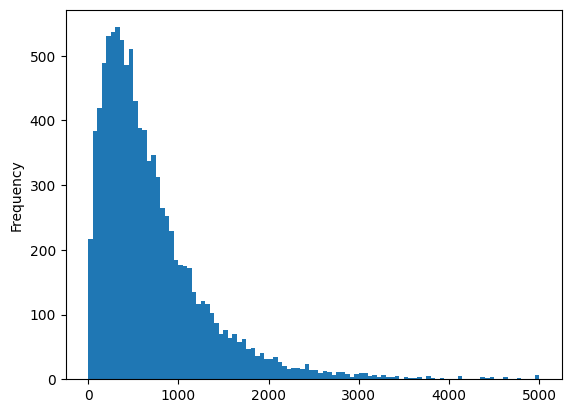

In [238]:
df['length'].plot(bins=100,kind='hist')

In [239]:
df.length.describe()

,length
count,10000.000000
mean,710.738700
std,617.399827
min,1.000000
25%,294.000000
50%,541.500000
75%,930.000000
max,4997.000000


In [240]:
df[df['length']==4997]['text'].iloc[0]

'In our continuing quest to identify cool, locally owned places to eat and/or drink, Caroline and I auditioned Vintage 95 last night. \n\nBefore I go further, understand that whenever I go out for eats or drinks, I have  in  mind a Platonic Ideal of the Bar/Pub/Eatery I most want to frequent. I\'m on a constant quest to find that  Ideal expressed in Real Life. \n\nVintage 95 isn\'t quite there, but it\'s damn close. If I ever give something Five Stars, you\'ll know it has pegged my Platonic Ideal. Anyway...\n\nThe plan last night was for drinks. No plans for food, just Adult Beverages and warm conversation. But it turned into more.\n\nThe location in downtown Chandler is terrific for us. The owners have created a very fine visual experience - leather, stone, dark woods, good lighting. And they don\'t have the music turned up so loud that you CANNOT HAVE A CONVERSATION. This is one of my pet peeves. If I want to stare at people move their mouths while enduring an aural assault, I\'ll st

In [241]:
df[df['length']==1]['text'].iloc[0]

'X'

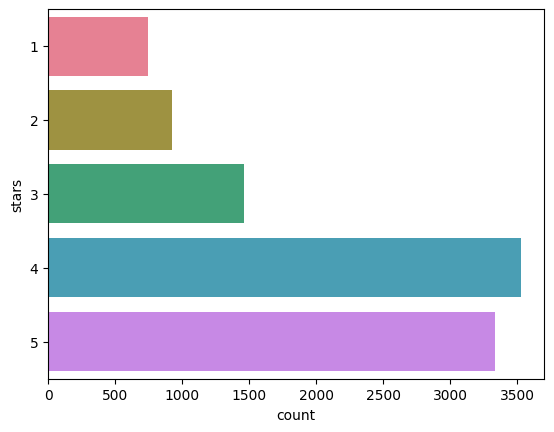

In [242]:
sns.countplot(df,y='stars',palette='husl')
plt.show()

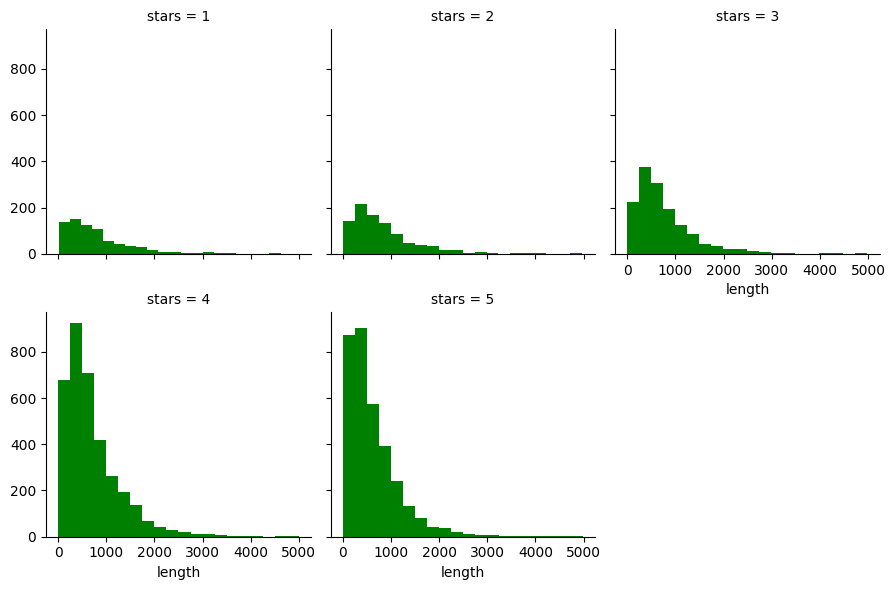

In [243]:
g=sns.FacetGrid(df,col='stars',col_wrap=3)
g.map(plt.hist,'length',bins=20,color='g')
plt.show()

In [244]:
df1=df[df['stars']==1]

In [245]:
df5=df[df['stars']==5]

In [246]:
df_15=pd.concat([df1,df5])

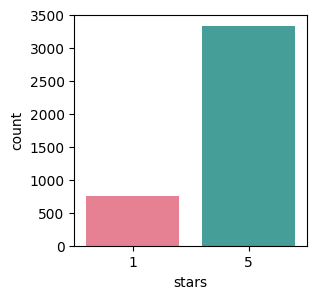

In [247]:
plt.figure(figsize=(3,3))
sns.countplot(df_15,x='stars',palette='husl')
plt.show()

In [248]:
df_15.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4086 entries, 23 to 9999
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    4086 non-null   object
 1   stars   4086 non-null   int64 
 2   text    4086 non-null   object
 3   cool    4086 non-null   int64 
 4   useful  4086 non-null   int64 
 5   funny   4086 non-null   int64 
 6   length  4086 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 255.4+ KB


In [249]:
print(f" 1-stars review percentage: {round((len(df1)/len(df_15))*100,2)} %  " )

 1-stars review percentage: 18.33 %  


In [250]:
print(f" 5-stars review percentage: {round((len(df5)/len(df_15))*100,2)} %  " )

 5-stars review percentage: 81.67 %  


**Text Preprocessing**

In [251]:
import string
import nltk
punc=string.punctuation
from nltk.corpus import stopwords
nltk.download('stopwords')
stop=stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [252]:
import re

In [253]:
def text_process(text):
  text=[w for w in text if w not in punc]
  text=''.join(text)
  text=[w for w in text.split() if w.lower() not in stop]
  return text

In [254]:
text_cleaned=df_15['text'].apply(text_process)

In [255]:
text_cleaned[22]

['first',
 'time',
 'friend',
 'went',
 'delicious',
 'food',
 'garlic',
 'knots',
 'favorite',
 'course',
 'wine',
 'going',
 'back',
 'ALOT']

**Count Vectorization**

In [256]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(analyzer=text_process)
X=cv.fit_transform(df_15['text'])

In [257]:
# len(countvector)

In [258]:
print(X.toarray())

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [259]:
X.shape

(4086, 26435)

**Model Devlopment**

In [260]:
y=df_15['stars'].values

In [261]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [262]:
from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

In [263]:
y_pred=model.predict(X_test)

In [264]:
y_test1=['amazing product! nice recommendation!']
y_test1=cv.transform(y_test1)
model.predict(y_test1)

array([5])

In [265]:
y_test2=['shit food! make me sick']
y_test2=cv.transform(y_test2)
model.predict(y_test2)

array([1])

In [266]:
from sklearn.metrics import classification_report,confusion_matrix

In [267]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.86      0.64      0.73       163
           5       0.92      0.97      0.94       655

    accuracy                           0.91       818
   macro avg       0.89      0.81      0.84       818
weighted avg       0.90      0.91      0.90       818



In [268]:
model.score(X_train,y_train)

0.9807221542227662

In [269]:
model.score(X_test,y_test)

0.9070904645476773

<Axes: >

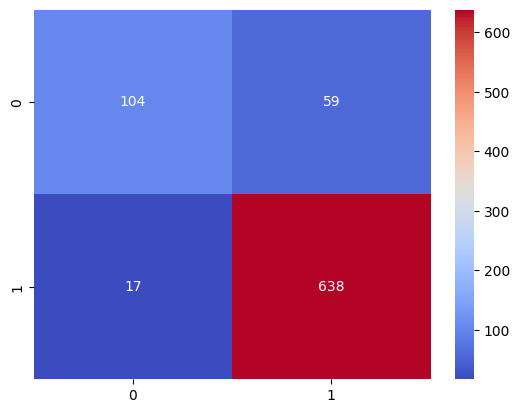

In [270]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='coolwarm')

# **TF-IDF**

In [271]:
from sklearn.feature_extraction.text import TfidfTransformer
tf=TfidfTransformer()
tfidf=tf.fit_transform(X)

In [272]:
tfidf.shape

(4086, 26435)

In [273]:
print(tfidf[ : , : ])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 222391 stored elements and shape (4086, 26435)>
  Coords	Values
  (0, 13)	0.15770246070234636
  (0, 244)	0.06662808805692144
  (0, 420)	0.15422766289715872
  (0, 5393)	0.1327453009849652
  (0, 6209)	0.1141876795265311
  (0, 7987)	0.09269421946314724
  (0, 8238)	0.4055847250304861
  (0, 8934)	0.13519490834349535
  (0, 9656)	0.07219908271873936
  (0, 9902)	0.06812247323449432
  (0, 10200)	0.1269033293873733
  (0, 10239)	0.06057181872889291
  (0, 10276)	0.1178689443031794
  (0, 10611)	0.1507384223657568
  (0, 10616)	0.10911986520282375
  (0, 10705)	0.08063615989954115
  (0, 10917)	0.08322016203495267
  (0, 11086)	0.3420650219404802
  (0, 11319)	0.10065657074960206
  (0, 11374)	0.07454031874473717
  (0, 12799)	0.14136742591085175
  (0, 14106)	0.053664531653196075
  (0, 14695)	0.1269033293873733
  (0, 15376)	0.21240370879621392
  (0, 15446)	0.08893343476250612
  :	:
  (4085, 14423)	0.10064506371832901
  (4085, 14480)	0.0851830257

In [277]:
X=tfidf
y=df_15['stars'].values

In [279]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.naive_bayes import MultinomialNB
model=MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

<Axes: >

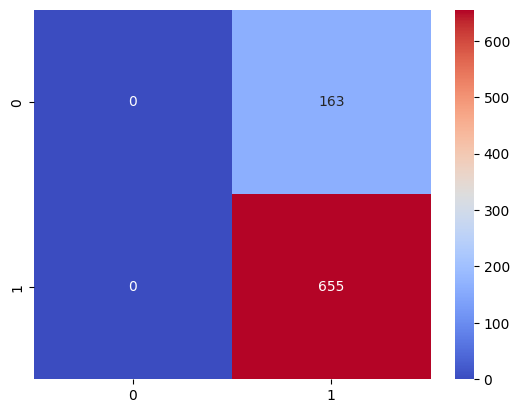

In [280]:
y_pred=model.predict(X_test)

cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='coolwarm')

In [281]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00       163
           5       0.80      1.00      0.89       655

    accuracy                           0.80       818
   macro avg       0.40      0.50      0.44       818
weighted avg       0.64      0.80      0.71       818

